In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Watch_History_Analysis") \
    .getOrCreate()

bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by bash)
bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by bash)
26/03/11 09:12:15 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/11 09:12:15 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/11 09:12:16 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Pleas

In [3]:
from datetime import datetime, timedelta

date = "2026-03-05"
required_days = 30

In [4]:
daily_watch_history_path = "gs://wynk-ml-workspace/projects/rails_reranking/daily_user_watch_history_new"
date_format = "%Y-%m-%d"
base_date = datetime.strptime(date, date_format)

paths = [
    f"{daily_watch_history_path}/day={(base_date - timedelta(days=i)).strftime(date_format)}"
    for i in range(required_days)
]

watch_history_df = None

for path in paths:
    try:
        temp_df = spark.read.parquet(path)

        if watch_history_df is None:
            watch_history_df = temp_df
        else:
            watch_history_df = watch_history_df.unionByName(temp_df)

    except Exception:
        print(f"Skipping missing path: {path}")

Skipping missing path: gs://wynk-ml-workspace/projects/rails_reranking/daily_user_watch_history_new/day=2026-02-06
Skipping missing path: gs://wynk-ml-workspace/projects/rails_reranking/daily_user_watch_history_new/day=2026-02-05


In [4]:
daily_click_watch_history_save_path = "gs://wynk-ml-workspace/projects/rails_reranking/daily_user_click_watch_history_new"
date_format = "%Y-%m-%d"

base_date = datetime.strptime(date, date_format)

paths = [
    f"{daily_click_watch_history_save_path}/day={(base_date - timedelta(days=i)).strftime(date_format)}"
    for i in range(required_days)
]

click_watch_df = None

for path in paths:
    try:
        temp_df = spark.read.parquet(path)

        if click_watch_df is None:
            click_watch_df = temp_df
        else:
            click_watch_df = click_watch_df.unionByName(temp_df)

    except Exception:
        print(f"Skipping missing path: {path}")



Skipping missing path: gs://wynk-ml-workspace/projects/rails_reranking/daily_user_click_watch_history_new/day=2026-02-06
Skipping missing path: gs://wynk-ml-workspace/projects/rails_reranking/daily_user_click_watch_history_new/day=2026-02-05


In [ ]:
watch_history_df.printSchema()
click_watch_df.printSchema()

root
 |-- userId: string (nullable = true)
 |-- item_id: string (nullable = true)
 |-- total_play_time_sec: double (nullable = true)
 |-- day: string (nullable = true)

root
 |-- userId: string (nullable = true)
 |-- item_id: string (nullable = true)
 |-- quality_click_flag: integer (nullable = true)
 |-- day: string (nullable = true)



In [10]:
watch_history_df.show(10, truncate=False)
click_watch_df.show(10, truncate=False)

+------------------+-----------------------------+-------------------+----------+
|userId            |item_id                      |total_play_time_sec|day       |
+------------------+-----------------------------+-------------------+----------+
|dT57CR8VGP2746Y1G0|CHAUPAL_MOVIE_en_movie_881   |17.261             |2026-03-05|
|iWVufEAU3FM_gJvyn0|ZEEFIVE_TVSHOW_0-6-4z5649768 |37.0               |2026-03-05|
|5bX0EMFcn6Tzw-6Fw0|ZEEFIVE_TVSHOW_0-6-4z5573866 |2558.0             |2026-03-05|
|Wlqa1bBrHyF92Y8SS0|ZEEFIVE_TVSHOW_0-6-4z5573866 |623.0              |2026-03-05|
|OZEVOHGP0ZaJhmdaW0|ZEEFIVE_TVSHOW_0-6-4z5573866 |1325.0             |2026-03-05|
|HxdF7qVxhyZBRAMwy0|ZEEFIVE_TVSHOW_0-6-4z5573866 |815.0              |2026-03-05|
|dpZi7E-0ha9XhtN310|SONYLIV_VOD_TVSHOW_1700000084|7966.346000000001  |2026-03-05|
|sNh-Z3eueq8owzX-K0|SONYLIV_VOD_TVSHOW_1790006675|1351.136           |2026-03-05|
|29Ddr6sjKEcLwkeDQ0|SONYLIV_VOD_TVSHOW_1700000084|738.0              |2026-03-05|
|WRdkKX3M-y8bxhF

In [5]:
import pyspark.sql.functions as F

# Your original approach, cleaned up
repeat_watchers_summary = (
    watch_history_df
    .groupBy("userId", "item_id")
    .count() # .count() is a direct shortcut for .agg(F.count("*"))
    .withColumnRenamed("count", "watch_count")
    .filter(F.col("watch_count") > 1)
)

print(repeat_watchers_summary.count())

6921189


## watch_history_df

In [6]:
import pyspark.sql.functions as F

# Select only required columns to reduce memory footprintry_df
    
combined_playtime = (
    watch_history_df  
    .groupBy("userId", "item_id")
    .agg(
        F.sum("total_play_time_sec").alias("total_playtime_combined"),
        F.count("*").alias("num_sessions")
    )
)
combined_playtime.cache().show(10, truncate=False)
user_distinct_content_count_df = (
    combined_playtime
    .groupBy("userId", "item_id")
    .agg(F.count_distinct("item_id").alias("distinct_content_count"))
)

+------------------+-----------------------------------------+-----------------------+------------+
|userId            |item_id                                  |total_playtime_combined|num_sessions|
+------------------+-----------------------------------------+-----------------------+------------+
|bN_zZKsOwpF0CaI5k0|SHEMAROOME_MOVIE_5f20071fa609d206c800aa88|2656.91                |1           |
|WAuzV3HristMUwEUL0|SONYLIV_VOD_TVSHOW_1700000084            |0.0                    |5           |
|29RFvnY7Ij6jHlrbz0|SONYLIV_VOD_TVSHOW_1790006756            |42538.23499999999      |10          |
|K2x_P4wA16jnHS1W30|SONYLIV_VOD_TVSHOW_1790006756            |54034.524000000005     |22          |
|9T3s2QXIV3dbA1OO20|SHEMAROOME_MOVIE_6538bbf7c47b711d65002261|59.274                 |1           |
|vIwyoSIeobi09ya3Q0|ZEEFIVE_TVSHOW_0-6-4z5646159             |31273.0                |8           |
|vqvWmMFvcQLYxkmmh0|ZEEFIVE_TVSHOW_0-6-4z5156060             |108.0                  |1           |


In [ ]:
user_distinct_content_count_df.show(10, truncate=False)

+------------------+---------------------------------------------------------------+----------------------+
|userId            |item_id                                                        |distinct_content_count|
+------------------+---------------------------------------------------------------+----------------------+
|vLa6kPiLFMiHX9UNw0|ZEEFIVE_TVSHOW_0-6-4z5880899                                   |1                     |
|4suMOcgtoFws1N1ex0|LIONSGATEPLAY_MOVIE_SNITCHY2013M                               |1                     |
|oeU2XvUOOxZDD6jzA0|CHAUPAL_TVSHOW_en_702d9003-f510-46b0-86cc-34832621391d         |1                     |
|9qB44q4BZIbpX997N0|MINITV_TVSHOW_amzn1.dv.gti.3bd7c93b-f4db-49ec-b5a1-377b314e700b|1                     |
|ZvYvTpMbOJkw8dRVM0|ZEEFIVE_TVSHOW_0-6-4z5414712                                   |1                     |
|2nmzYWr1hPViIFfuy0|ZEEFIVE_TVSHOW_0-6-4z5364077                                   |1                     |
|tuyBvWqTJ8A-2_bpr0|ZEEFIVE_

26/03/10 12:08:20 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 13 for reason Executor for container container_1764236692086_4834_01_000021 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.


### Analysis

/tmp/ipykernel_4125959/3931902583.py:20: FutureWarning:                         

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


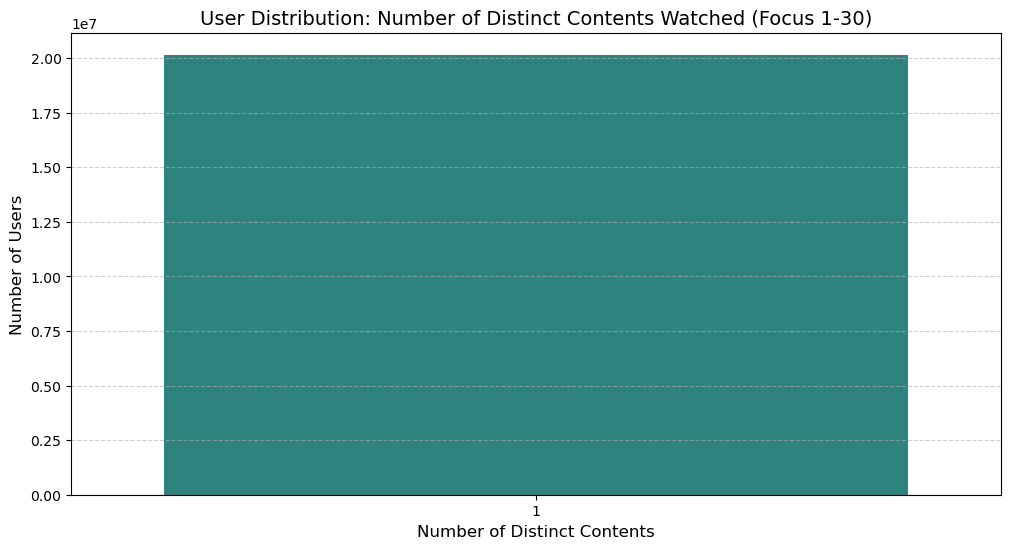

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate: Count how many users fall into each "content count" bucket
# We sort by the count of contents to make the X-axis linear (1, 2, 3...)
dist_data = (
    user_distinct_content_count_df
    .groupBy("distinct_content_count")
    .count()
    .orderBy("distinct_content_count")
)

# 2. Focus on "Lower Numbers": Filter for users with 1 to 30 contents 
# This prevents high-count outliers from squishing the graph
plot_df = dist_data.filter("distinct_content_count <= 30").toPandas()
# plot_df = dist_data.toPandas()

# 3. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    x="distinct_content_count", 
    y="count", 
    data=plot_df, 
    palette="viridis"
)

# Adding labels and styling
plt.title("User Distribution: Number of Distinct Contents Watched (Focus 1-30)", fontsize=14)
plt.xlabel("Number of Distinct Contents", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.show()

In [8]:
print("Users watching  1 content:\t", user_distinct_content_count_df.filter("distinct_content_count == 1").count())
print("Users watching  2 content:\t", user_distinct_content_count_df.filter("distinct_content_count == 2").count())
print("Users watching  3 content:\t", user_distinct_content_count_df.filter("distinct_content_count == 3").count())
print("Users watching  5 content:\t", user_distinct_content_count_df.filter("distinct_content_count == 5").count())
print("Users watching  10 content:\t", user_distinct_content_count_df.filter("distinct_content_count == 10").count())
print("Users watching  20 content:\t", user_distinct_content_count_df.filter("distinct_content_count == 20").count())
print("Users watching >= 50 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 50").count())
print("Users watching >= 100 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 100").count())

Users watching  1 content:	 20155441


Users watching  2 content:	 0


Users watching  3 content:	 0


Users watching  5 content:	 0


Users watching  10 content:	 0


Users watching  20 content:	 0


Users watching >= 50 content:	 0


Users watching >= 100 content:	 0


In [9]:
# Define the percentiles you want (expressed as decimals 0.0 to 1.0)
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

# Calculate the values
# 0.01 is the relative error: lower is more accurate but slower
quantile_values = user_distinct_content_count_df.stat.approxQuantile(
    "distinct_content_count", 
    percentiles, 
    0.01
)

# Pair them up and print the results
print("--- User Content Consumption Percentiles ---")
for p, v in zip(percentiles, quantile_values):
    print(f"{int(p*100)}th Percentile: {int(v)} contents")

--- User Content Consumption Percentiles ---
25th Percentile: 1 contents
50th Percentile: 1 contents
75th Percentile: 1 contents
90th Percentile: 1 contents
95th Percentile: 1 contents
99th Percentile: 1 contents


In [18]:
user_distinct_content_count_df.show(10, truncate=False)

+------------------+----------------------+
|userid            |distinct_content_count|
+------------------+----------------------+
|hWX1mJcFqCu16kuRb0|35                    |
|HuYhlWQpyBV1uoJ7U0|7                     |
|2mM8xhw1T8zwL9i3d0|1                     |
|xrjyChwGLVXbvkpDw0|4                     |
|TWCRbPu0YzCTY5kzc0|7                     |
|t1t559t5r-Qh58e500|19                    |
|AV0eF9lKJ3q4Hmy8O0|11                    |
|1v8ZYPqRhh42fAr1x0|4                     |
|8f6gwozXJ4qIUAxtL0|26                    |
|WoNgdGfnPrsVLo1KB0|19                    |
+------------------+----------------------+
only showing top 10 rows



## Refactored code

In [7]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

# 1. Aggregate Playtime and Count Distinct items per user in one flow
user_stats = (
    watch_history_df  
    .groupBy("userId", "item_id")
    .agg(
        F.sum("total_play_time_sec").alias("total_playtime_combined")
    )
    # We add a column to count how many distinct items EACH user has watched
    .withColumn("distinct_content_count", F.count("item_id").over(Window.partitionBy("userId")))
)

# 2. Filter for users with at least 3 distinct items
als_input_base = user_stats.filter("distinct_content_count >= 3")

# 3. Create Lookups (Indices)
user_window = Window.orderBy("userId")
item_window = Window.orderBy("item_id")

user_lookup = als_input_base.select("userId").distinct().withColumn("userIndex", row_number().over(user_window))
item_lookup = als_input_base.select("item_id").distinct().withColumn("itemIndex", row_number().over(item_window))

# 4. Final Join to prepare ALS data
als_data = (
    als_input_base
    .join(user_lookup, "userId")
    .join(item_lookup, "item_id")
    .select(
        "userIndex",
        "itemIndex",
        F.log1p("total_playtime_combined").alias("playtime_logged") # Applying log here to handle skewness
    )
    .repartition(500) 
)

# sanity check

als_data = als_data.filter(
    F.col("playtime_logged").isNotNull()
).filter(
    ~F.isnan("playtime_logged")
)

# 5. Train ALS
from pyspark.ml.recommendation import ALS

als = ALS(
    userCol="userIndex",
    itemCol="itemIndex",
    ratingCol="playtime_logged", # Using the logged playtime
    implicitPrefs=True,
    rank=20,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop"
)

model = als.fit(als_data)

26/03/11 09:27:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:27:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:27:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:27:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:27:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:27:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 0

In [8]:
# Generate top 10 recs for every user
# This creates a column 'recommendations' which is an array of [itemIndex, rating]
recommendations = model.recommendForAllUsers(10)
recommendations.show(10, truncate=False)

from pyspark.sql.functions import col, explode

# 1. Explode ALL recommendations for ALL users
all_recs_exploded = recommendations.select(
    col("userIndex"),
    explode("recommendations").alias("rec")
).select(
    "userIndex",
    col("rec.itemIndex").alias("itemIndex"),
    col("rec.rating").alias("score")
)

# 2. Perform a Global Anti-Join 
# This removes EVERY user-item pair that already exists in your training data
clean_recommendations = all_recs_exploded.join(
    als_data, # Your original training data
    on=["userIndex", "itemIndex"], 
    how="left_anti"
)

# 3. Cache this "Clean" version
clean_recommendations.cache()

26/03/11 09:31:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:31:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:31:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:31:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+---------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|userIndex|recommendations                                                                                                                                                                                                |
+---------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|65       |[{8128, 0.78872895}, {26413, 0.67074376}, {26519, 0.65886253}, {8126, 0.63951415}, {16680, 0.6233668}, {819, 0.55656505}, {47, 0.52809453}, {8123, 0.52699274}, {25926, 0.49954373}, {25929, 0.49852252}]      |
|148      |[{22556, 0.75682807}, {22561, 0.7330971}, {22564, 0.5556384}, {22539, 0.42627922}, {26428, 0.39869633}, {2251

DataFrame[userIndex: int, itemIndex: int, score: float]

In [ ]:
# Pick a random user index from the CLEANED recommendations
random_user_idx = clean_recommendations.select("userIndex").sample(False, 0.1).limit(1).first()[0]

print(f"--- Recommendations for User Index: {random_user_idx} ---")

# Show History
print("\n[ History ]")
history = als_data.filter(col("userIndex") == random_user_idx).join(item_lookup, "itemIndex")

# Show Clean Recs
print("\n[ New Suggestions Only ]")
reco_10 = (clean_recommendations
    .filter(col("userIndex") == random_user_idx)
    .join(item_lookup, "itemIndex")
    .orderBy(col("score").desc())
    .limit(10))

history.show(10, truncate=False)
reco_10.show(10, truncate=False)

26/03/11 09:31:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:31:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:31:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:31:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:31:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:31:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 0

--- Recommendations for User Index: 127109 ---

[ History ]


26/03/11 09:32:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:32:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:32:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:32:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:32:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:32:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 0

+---------+---------+------------------+-----------------------------------------+
|itemIndex|userIndex|playtime_logged   |item_id                                  |
+---------+---------+------------------+-----------------------------------------+
|8123     |127109   |8.99256675173937  |HUNGAMA_TVSHOW_124537221                 |
|15734    |127109   |3.1771784473119915|SHEMAROOME_MOVIE_6100268da609d2281c001a36|
|10364    |127109   |2.8816112744492917|LIONSGATEPLAY_MOVIE_TILLDEATHY2021MHI    |
|2066     |127109   |2.4943618085587556|DOCUBAY_MOVIE_4757                       |
|8124     |127109   |5.114490677610777 |HUNGAMA_TVSHOW_124541729                 |
|15639    |127109   |3.1527787564932748|SHEMAROOME_MOVIE_60d35e1ea609d2066801953d|
|15731    |127109   |2.8028754148446535|SHEMAROOME_MOVIE_6100267ba609d2281c001a26|
|10458    |127109   |5.222278300262447 |LIONSGATEPLAY_TVSHOW_EROTICSTORIESY2023S |
+---------+---------+------------------+-----------------------------------------+


[ 

26/03/11 09:32:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:32:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:32:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:32:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:32:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:32:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 0

+---------+---------+----------+------------------------------------------+
|itemIndex|userIndex|score     |item_id                                   |
+---------+---------+----------+------------------------------------------+
|8128     |127109   |0.6890153 |HUNGAMA_TVSHOW_124553869                  |
|16680    |127109   |0.58275   |SHEMAROOME_TVSHOW_6985b3e99ce2e63f35467420|
|8126     |127109   |0.53212583|HUNGAMA_TVSHOW_124548472                  |
|16672    |127109   |0.46919522|SHEMAROOME_TVSHOW_67a9ae2378457a41ed000124|
|16542    |127109   |0.4218762 |SHEMAROOME_MOVIE_693bf6553c02b56dfce72af0 |
|16338    |127109   |0.41847065|SHEMAROOME_MOVIE_670fc6e0c47b7141180034e4 |
|8100     |127109   |0.41219017|HUNGAMA_TVSHOW_124302597                  |
+---------+---------+----------+------------------------------------------+



In [10]:
item_factors = model.itemFactors
item_factors.show(10, truncate=False)

+---+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|id |features                                                                                                                                                                                                                                                                                      |
+---+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|10 |[4.1178002E-5, -4.7446726E-4, 2.640671E-4, 1.8208745E-4, 1.08886365E-4, -2.848039E-4, -1.2185972E-4, 2.5495885E-5, 2

In [ ]:
# Join the latent factors with the human-readable item IDs
item_features_final = (
    model.itemFactors
    .join(item_lookup, col("id") == col("itemIndex"))
    .select(
        "item_id",      # Your actual content ID/Name
        "itemIndex",    # The integer used by ALS
        "features"      # The latent vector [rank_1, rank_2, ...]
    )
)

import pyspark.sql.functions as F
from pyspark.sql.functions import col

# --- CONFIGURATION ---
TARGET_ITEM_ID = "HUNGAMA_TVSHOW_124537221"  # Replace with the actual ID you want to look up
# ---------------------

# 1. Get the vector for your target item
target_row = item_features_final.filter(col("item_id") == TARGET_ITEM_ID).select("features").first()

if not target_row:
    print(f"Item {TARGET_ITEM_ID} not found in the dataset.")
else:
    target_vector = target_row[0]
    num_features = len(target_vector)

    # 2. Calculate Similarity (Dot Product)
    # This creates a column where we multiply target[i] * features[i] for every dimension
    similar_items = (
        item_features_final
        .withColumn("similarity_score", 
            sum(col("features")[i] * target_vector[i] for i in range(num_features))
        )
        # 3. Filter out the item itself so you don't recommend the same thing
        .filter(col("item_id") != TARGET_ITEM_ID)
        .select("item_id", "similarity_score")
        .orderBy(col("similarity_score").desc())
        .limit(10)
    )

    print(f"✨ Items most similar to: {TARGET_ITEM_ID}")
    similar_items.show(truncate=False)

# item_features_final.show(10, truncate=False)

26/03/11 09:43:26 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:43:26 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:43:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:43:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:43:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:43:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 0

✨ Items most similar to: HUNGAMA_TVSHOW_124537221


26/03/11 09:43:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:43:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:43:29 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/11 09:43:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:43:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 09:43:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data

+------------------------------------------+------------------+
|item_id                                   |similarity_score  |
+------------------------------------------+------------------+
|HUNGAMA_TVSHOW_124553869                  |1.5802520264269706|
|SHEMAROOME_TVSHOW_6985b3e99ce2e63f35467420|1.3474995394875224|
|HUNGAMA_TVSHOW_124548472                  |1.2708254245008577|
|SHEMAROOME_TVSHOW_67a9ae2378457a41ed000124|0.9895207385810927|
|SHEMAROOME_MOVIE_693bf6553c02b56dfce72af0 |0.9104405099789359|
|HUNGAMA_TVSHOW_124302597                  |0.9084691335238926|
|HUNGAMA_TVSHOW_124512813                  |0.8952131413134214|
|SHEMAROOME_MOVIE_670fc6e0c47b7141180034e4 |0.8746481060991034|
|HUNGAMA_TVSHOW_96772296                   |0.8687564196743873|
|SHEMAROOME_MOVIE_677bd835c47b7122e100004e |0.8294621958444663|
+------------------------------------------+------------------+



26/03/11 09:51:24 WARN DAGScheduler: Broadcasting large task binary with size 15.5 MiB
26/03/11 09:51:25 WARN DAGScheduler: Broadcasting large task binary with size 46.1 MiB
26/03/11 09:57:01 WARN TaskSetManager: Lost task 5.0 in stage 237.0 (TID 21591) (dprc-wynk-prd-data-ds-machine-learning-common-sw-d8s5.c.prj-wynk-prd-ds-svc-01.internal executor 16): org.apache.spark.storage.BlockSavedOnDecommissionedBlockManagerException: Block taskresult_21591 cannot be saved on decommissioned executor
	at org.apache.spark.errors.SparkCoreErrors$.cannotSaveBlockOnDecommissionedExecutorError(SparkCoreErrors.scala:323)
	at org.apache.spark.storage.BlockManager.checkShouldStore(BlockManager.scala:284)
	at org.apache.spark.storage.BlockManager.org$apache$spark$storage$BlockManager$$doPut(BlockManager.scala:1514)
	at org.apache.spark.storage.BlockManager$BlockStoreUpdater.save(BlockManager.scala:385)
	at org.apache.spark.storage.BlockManager.putBytes(BlockManager.scala:1473)
	at org.apache.spark.execu

In [ ]:
recommendations.show(10, truncate=False)

+---------+---------+----------+
|userIndex|itemIndex|score     |
+---------+---------+----------+
|19       |22539    |0.6505414 |
|28       |25886    |0.63621294|
|55       |11339    |0.5135539 |
|61       |22573    |0.24396153|
|67       |22412    |0.4603798 |
|89       |47       |0.174102  |
|98       |20443    |0.19225556|
|105      |22562    |0.45086533|
|110      |1682     |0.6146602 |
|124      |26519    |0.70211196|
+---------+---------+----------+
only showing top 10 rows



26/03/10 12:32:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 12:32:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 12:32:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 12:32:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


### ALS implementation

In [ ]:
# #test for row numbers
# from pyspark.sql.window import Window
# from pyspark.sql.functions import row_number

# user_distinct_content_count_df = user_distinct_content_count_df.filter("distinct_content_count >= 3")

# user_window = Window.orderBy("userId")

# user_lookup = (
#     user_distinct_content_count_df
#     .select("userId")
#     .distinct()
#     .withColumn("userIndex", row_number().over(user_window))
# )   
# item_window = Window.orderBy("item_id")

# item_lookup = (
#     user_distinct_content_count_df
#     .select("item_id")
#     .distinct()
#     .withColumn("itemIndex", row_number().over(item_window))
# )

# als_data = (
#     user_distinct_content_count_df
#     .join(user_lookup, "userId")
#     .join(item_lookup, "item_id")
# )   
# als_data = als_data.select(
#     "userIndex",
#     "itemIndex",
#     "playtime"
#     ).repartition(5000)

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `rating_label_custom` cannot be resolved. Did you mean one of the following? [`distinct_content_count`, `item_id`, `itemIndex`, `userId`, `userIndex`].;
'Project [userIndex#5545, itemIndex#5550, 'rating_label_custom]
+- Project [item_id#3418, userId#3417, distinct_content_count#5459L, userIndex#5545, itemIndex#5550]
   +- Join Inner, (item_id#3418 = item_id#5697)
      :- Project [userId#3417, item_id#3418, distinct_content_count#5459L, userIndex#5545]
      :  +- Join Inner, (userId#3417 = userId#5553)
      :     :- Filter (distinct_content_count#5459L >= cast(3 as bigint))
      :     :  +- Aggregate [userId#3417, item_id#3418], [userId#3417, item_id#3418, count(distinct item_id#3418) AS distinct_content_count#5459L]
      :     :     +- Aggregate [userId#3417, item_id#3418], [userId#3417, item_id#3418, sum(total_play_time_sec#3419) AS total_playtime_combined#5351, count(1) AS num_session

In [ ]:
# from pyspark.ml.recommendation import ALS

# als = ALS(
#     userCol="userIndex",
#     itemCol="itemIndex",
#     ratingCol="rating_label_custom", #using log because of skewness in playtime distribution
#     implicitPrefs=True,
#     rank=20,
#     maxIter=10,
#     regParam=0.1,
#     coldStartStrategy="drop"
# )

# model = als.fit(als_data)

# # Cache model predictions for reuse
# recommendations = model.recommendForAllUsers(10)
# recommendations.cache()

## data presentation

In [ ]:
from pyspark.sql.functions import col, explode

# 1. Pick a random user from your recommendations
random_user_df = recommendations.orderBy("userIndex").limit(100).sample(False, 0.1).limit(1)
target_user_index = random_user_df.select("userIndex").first()[0]

print(f"--- Results for User Index: {target_user_index} ---")

# 2. Get Watch History
# We join back to your original item_lookup to see what they actually watched
print("\n[ Recent Watch History ]")
user_history = (
    als_data.filter(col("userIndex") == target_user_index)
    .join(item_lookup, "itemIndex")
    .select("item_id")
)
user_history.show(truncate=False)

# 3. Get Recommendations
# Explode the 'recommendations' array into rows
print("[ Generated Recommendations ]")
user_recs = (
    recommendations.filter(col("userIndex") == target_user_index)
    .withColumn("rec", explode("recommendations"))
    .select(
        col("rec.itemIndex").alias("itemIndex"), 
        col("rec.rating").alias("predicted_rating")
    )
    .join(item_lookup, "itemIndex")
    .select("item_id", "predicted_rating")
)
user_recs.show(truncate=False)

## click_watch_df

## Light fM

In [1]:
!pip install lightfm

/bin/bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 3.8 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for lightfm: filename=lightfm-1.17-cp311-cp311-linux_x86_64.whl size=437877 sha256=0e02a29c3f95c2a14207b5f92937127caf9b5cfb1afa00828db51aa5aa2a28b7
  Stored in directory: /home/B0336827/.cache/pip/wheels/b9/0d/8a/0729d2e6e3ca2a898ba55201f905da7db3f838a33df5b3fcdd
Successfully built lightfm


In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("lightfm_with_meta") \
    .getOrCreate()

bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by bash)
bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by bash)
26/03/13 06:41:24 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/13 06:41:24 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/13 06:41:24 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Pleas

In [2]:
enriched_db_path = "gs://wynk-ml-workspace/projects/xstream_nlu/catalog-db/" 

enriched_tv_df = spark.read.parquet(f'{enriched_db_path}{date}/enriched_tv.parquet')
enriched_movies_df = spark.read.parquet(f'{enriched_db_path}{date}/enriched_movie.parquet')

NameError: name 'date' is not defined

In [2]:
import pandas as pd
import numpy as np
from lightfm import LightFM
from lightfm.data import Dataset
from scipy.sparse import csr_matrix

# 1. Convert Spark Data to Pandas (Only do this for the ID columns)
# LightFM needs a local sparse matrix, so we bring the IDs to the driver
interactions_pd = als_data_final.select("userId", "item_id", "playtime_logged").toPandas()

# 2. Map IDs to Internal Indices
# LightFM's Dataset class handles the indexing for you automatically
dataset = Dataset()
dataset.fit(
    users=interactions_pd['userId'].unique(),
    items=interactions_pd['item_id'].unique()
)

# 3. Build the Interaction Matrix
(interactions, weights) = dataset.build_interactions(
    (row.userId, row.item_id, row.playtime_logged) 
    for row in interactions_pd.itertuples()
)

# 4. Define and Train the Model
# 'warp' loss is industry standard for "Top-N" recommendations
model = LightFM(loss='warp', no_components=30, learning_rate=0.05)

# Train using all available cores (num_threads)
model.fit(interactions, sample_weight=weights, epochs=20, num_threads=4)

print("✅ LightFM Model Trained!")

ModuleNotFoundError: No module named 'lightfm'

In [ ]:
# Create a list of all unique genres
unique_genres = enriched_content_df.select("Genres").distinct().toPandas()["Genres"].tolist()

# Tell the dataset about these features
dataset.fit_partial(items=interactions_pd['item_id'].unique(), item_features=unique_genres)

# Build the item features matrix
item_features = dataset.build_item_features(
    (row.item_id, [row.Genres]) for row in enriched_content_df.toPandas().itertuples()
)

# Train with features
model.fit(interactions, item_features=item_features, epochs=20, num_threads=4)